# 05 — Pré-processamento das Variáveis

Este notebook define a estratégia de pré-processamento que será utilizada na comparação dos quatro classificadores previstos no estudo:

- Regressão Logística;
- K-Nearest Neighbors (KNN);
- Random Forest;
- Gradient Boosting.

O objetivo **não é treinar modelos nesta etapa**, mas compreender como as características dos atributos categóricos influenciam sua representação matemática e estabelecer um procedimento de pré-processamento coerente com cada família de algoritmo.

## Princípios metodológicos

1. O pré-processamento faz parte do processo de modelagem e não deve ser aprendido utilizando dados futuros.
2. Qualquer transformação dependente dos dados será ajustada exclusivamente no conjunto de **treino**.
3. O conjunto de **teste** poderá ser utilizado para avaliação posterior, mas não para aprender categorias, frequências ou parâmetros de transformação.
4. O conjunto **out-of-time (OOT)** permanecerá isolado e não será utilizado neste notebook.
5. Não será criado um CSV global previamente codificado. As transformações serão posteriormente incorporadas aos `Pipeline` dos modelos.


## 1. Bibliotecas e configurações


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Diretórios e carregamento da base preparada


In [2]:
PROJECT_DIR = Path(r"C:\UnB\script_md")
PROCESSADOS_DIR = PROJECT_DIR / "Base de dados" / "processados"

FIGURES_DIR = PROJECT_DIR / "outputs" / "figuras"
TABLES_DIR = PROJECT_DIR / "outputs" / "tabelas"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = PROCESSADOS_DIR / "dataset_modelagem_preparado.csv"

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {INPUT_FILE}. "
        "Execute primeiro o notebook 03_preparacao_dados.ipynb."
    )

df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

print(f"Base carregada: {len(df):,} registros x {df.shape[1]} colunas")


Base carregada: 58,131 registros x 16 colunas


## 3. Preditores e separação temporal

A análise de pré-processamento utiliza somente o conjunto de treino para aprender características das variáveis.

O conjunto de teste é consultado apenas para **diagnosticar categorias não vistas no treino**. Nenhuma decisão será ajustada para maximizar desempenho no teste.

O OOT permanece completamente reservado.


In [3]:
PREDITORES = [
    "Região",
    "UF",
    "Cidade",
    "Sexo",
    "Faixa Etária",
    "Área",
    "Assunto",
    "Grupo Problema",
    "Problema",
    "Como Comprou Contratou",
    "Procurou Empresa"
]

df_train = df[df["Amostra"] == "Treino"].copy()
df_test = df[df["Amostra"] == "Teste"].copy()

n_oot_reservado = int((df["Amostra"] == "OOT").sum())

X_train = df_train[PREDITORES].copy()
X_test = df_test[PREDITORES].copy()

print(f"Treino utilizado para estudar o pré-processamento: {len(X_train):,}")
print(f"Teste disponível apenas para diagnóstico de cobertura: {len(X_test):,}")
print(f"OOT reservado e não utilizado: {n_oot_reservado:,}")


Treino utilizado para estudar o pré-processamento: 12,032
Teste disponível apenas para diagnóstico de cobertura: 14,027
OOT reservado e não utilizado: 32,072


## 4. Cardinalidade no conjunto de treino

A cardinalidade corresponde ao número de categorias distintas observadas em cada atributo.

Variáveis de alta cardinalidade podem aumentar substancialmente o número de dimensões quando representadas por One-Hot Encoding.


In [4]:
cardinalidade_treino = pd.DataFrame({
    "Variável": PREDITORES,
    "Categorias no treino": [
        X_train[coluna].nunique(dropna=False)
        for coluna in PREDITORES
    ]
}).sort_values(
    "Categorias no treino",
    ascending=False
)

display(cardinalidade_treino)

cardinalidade_treino.to_csv(
    TABLES_DIR / "preprocessamento_cardinalidade_treino.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Variável,Categorias no treino
2,Cidade,1774
8,Problema,85
1,UF,27
6,Assunto,27
9,Como Comprou Contratou,9
7,Grupo Problema,8
4,Faixa Etária,7
0,Região,5
3,Sexo,3
5,Área,3


## 5. Categorias raras no conjunto de treino

Alta cardinalidade não implica necessariamente que grande parte das observações esteja distribuída entre categorias raras.

Por isso, além de contar categorias pouco frequentes, calculamos também o percentual de **registros** que pertence a essas categorias.

São examinados três limites descritivos:

- frequência inferior a 2 registros;
- frequência inferior a 5 registros;
- frequência inferior a 10 registros.

Esses limites são utilizados apenas para caracterização. A escolha de eventual agrupamento de categorias raras deverá ser tratada posteriormente como parte do protocolo de modelagem.


In [5]:
limites_raridade = [2, 5, 10]

linhas_raridade = []

for coluna in PREDITORES:
    frequencias = X_train[coluna].value_counts(dropna=False)

    linha = {
        "Variável": coluna,
        "Categorias totais": len(frequencias)
    }

    for limite in limites_raridade:
        categorias_raras = frequencias[
            frequencias < limite
        ]

        registros_raros = int(
            categorias_raras.sum()
        )

        linha[f"Categorias freq < {limite}"] = len(categorias_raras)
        linha[f"Registros em categorias freq < {limite} (%)"] = round(
            registros_raros / len(X_train) * 100,
            2
        )

    linhas_raridade.append(linha)

raridade = pd.DataFrame(linhas_raridade).sort_values(
    "Categorias totais",
    ascending=False
)

display(raridade)

raridade.to_csv(
    TABLES_DIR / "preprocessamento_categorias_raras.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Variável,Categorias totais,Categorias freq < 2,Registros em categorias freq < 2 (%),Categorias freq < 5,Registros em categorias freq < 5 (%),Categorias freq < 10,Registros em categorias freq < 10 (%)
2,Cidade,1774,832,6.91,1404,19.13,1597,29.21
8,Problema,85,6,0.05,18,0.34,22,0.59
1,UF,27,0,0.00,0,0.00,0,0.00
6,Assunto,27,1,0.01,3,0.06,7,0.27
9,Como Comprou Contratou,9,0,0.00,0,0.00,1,0.07
7,Grupo Problema,8,0,0.00,0,0.00,0,0.00
4,Faixa Etária,7,0,0.00,0,0.00,0,0.00
0,Região,5,0,0.00,0,0.00,0,0.00
3,Sexo,3,0,0.00,1,0.02,1,0.02
5,Área,3,0,0.00,0,0.00,0,0.00


### 5.1 Registros associados a categorias muito raras


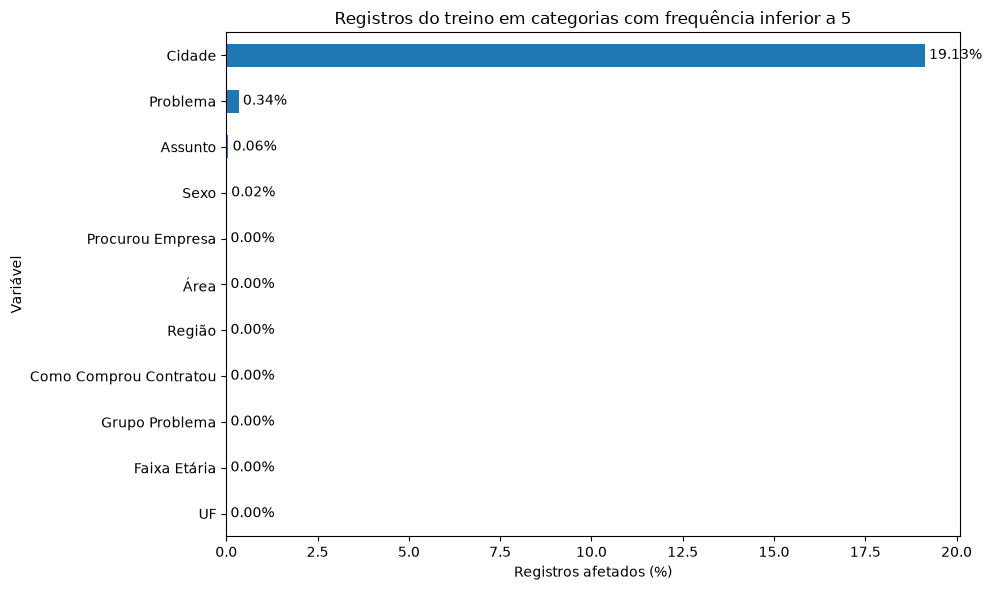

In [6]:
dados_plot = (
    raridade
    .set_index("Variável")["Registros em categorias freq < 5 (%)"]
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))

dados_plot.plot(
    kind="barh",
    ax=ax
)

ax.set_title("Registros do treino em categorias com frequência inferior a 5")
ax.set_xlabel("Registros afetados (%)")
ax.set_ylabel("Variável")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "preprocessamento_categorias_raras_treino.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 6. Categorias não vistas no conjunto de teste

Para cada atributo, são identificadas categorias presentes no teste que não estavam disponíveis no treino.

A quantidade de categorias novas é acompanhada pelo percentual de **observações do teste afetadas**, pois uma grande quantidade de categorias raras pode representar apenas pequena parcela da população.


In [7]:
linhas_cobertura = []

for coluna in PREDITORES:
    categorias_treino = set(
        X_train[coluna]
        .dropna()
        .astype(str)
        .unique()
    )

    categorias_teste = set(
        X_test[coluna]
        .dropna()
        .astype(str)
        .unique()
    )

    categorias_novas = categorias_teste - categorias_treino

    mascara_nova = (
        X_test[coluna]
        .astype(str)
        .isin(categorias_novas)
    )

    registros_afetados = int(mascara_nova.sum())

    linhas_cobertura.append({
        "Variável": coluna,
        "Categorias no treino": len(categorias_treino),
        "Categorias no teste": len(categorias_teste),
        "Categorias novas no teste": len(categorias_novas),
        "Registros afetados": registros_afetados,
        "Registros afetados (%)": round(
            registros_afetados / len(X_test) * 100,
            2
        )
    })

cobertura_teste = pd.DataFrame(linhas_cobertura).sort_values(
    "Registros afetados (%)",
    ascending=False
)

display(cobertura_teste)

cobertura_teste.to_csv(
    TABLES_DIR / "preprocessamento_categorias_nao_vistas_teste.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Variável,Categorias no treino,Categorias no teste,Categorias novas no teste,Registros afetados,Registros afetados (%)
2,Cidade,1774,2042,874,1403,10.00
8,Problema,85,80,2,4,0.03
6,Assunto,27,27,1,2,0.01
1,UF,27,27,0,0,0.00
0,Região,5,5,0,0,0.00
4,Faixa Etária,7,7,0,0,0.00
3,Sexo,3,3,0,0,0.00
5,Área,3,3,0,0,0.00
7,Grupo Problema,8,8,0,0,0.00
9,Como Comprou Contratou,9,9,0,0,0.00


### 6.1 Exposição do teste a categorias não vistas


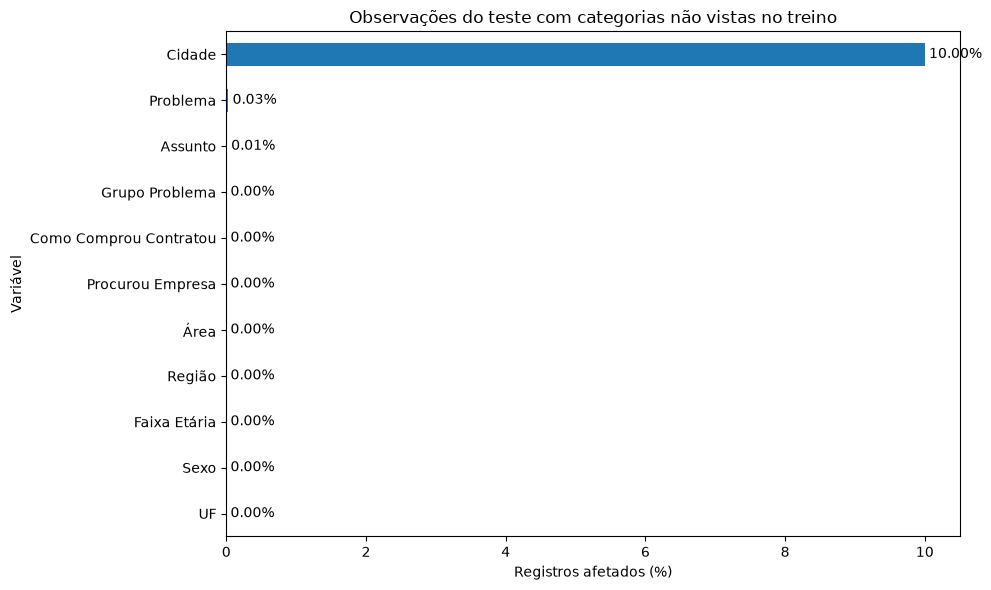

In [8]:
dados_plot = (
    cobertura_teste
    .set_index("Variável")["Registros afetados (%)"]
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))

dados_plot.plot(
    kind="barh",
    ax=ax
)

ax.set_title("Observações do teste com categorias não vistas no treino")
ax.set_xlabel("Registros afetados (%)")
ax.set_ylabel("Variável")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "preprocessamento_categorias_nao_vistas_teste.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 7. Impacto dimensional do One-Hot Encoding

O One-Hot Encoding é particularmente natural para variáveis nominais porque evita introduzir uma ordenação artificial entre suas categorias.

Nesta etapa, o encoder é ajustado **somente no treino** para quantificar o aumento do número de atributos.

Nenhum classificador é treinado.


In [9]:
def criar_ohe(min_frequency=None):
    """Cria OneHotEncoder compatível com versões recentes e anteriores do scikit-learn."""
    parametros = {
        "handle_unknown": "ignore",
        "min_frequency": min_frequency
    }

    try:
        return OneHotEncoder(
            sparse_output=True,
            **parametros
        )
    except TypeError:
        return OneHotEncoder(
            sparse=True,
            **parametros
        )


In [10]:
ohe_sem_agrupamento = criar_ohe(
    min_frequency=None
)

X_train_ohe = ohe_sem_agrupamento.fit_transform(
    X_train
)

n_features_ohe = X_train_ohe.shape[1]

print(f"Variáveis originais: {len(PREDITORES)}")
print(f"Features após OHE sem agrupamento: {n_features_ohe:,}")
print(f"Dimensão da matriz de treino: {X_train_ohe.shape}")


Variáveis originais: 11
Features após OHE sem agrupamento: 1,950
Dimensão da matriz de treino: (12032, 1950)


## 8. Análise exploratória de agrupamento de categorias raras

O `OneHotEncoder` permite agrupar categorias pouco frequentes por meio do parâmetro `min_frequency`.

Para **não escolher esse parâmetro com base no conjunto de teste**, o efeito dimensional é analisado exclusivamente no treino.

Os valores abaixo são candidatos exploratórios e não representam ainda hiperparâmetros definitivos.


In [11]:
frequencias_candidatas = [
    None,
    2,
    5,
    10,
    20
]

linhas_dimensionalidade = []

for frequencia in frequencias_candidatas:
    encoder = criar_ohe(
        min_frequency=frequencia
    )

    matriz = encoder.fit_transform(
        X_train
    )

    linhas_dimensionalidade.append({
        "min_frequency": (
            "Sem agrupamento"
            if frequencia is None
            else frequencia
        ),
        "Features geradas": matriz.shape[1],
        "Registros treino": matriz.shape[0]
    })

dimensionalidade_ohe = pd.DataFrame(
    linhas_dimensionalidade
)

display(dimensionalidade_ohe)

dimensionalidade_ohe.to_csv(
    TABLES_DIR / "preprocessamento_dimensionalidade_ohe.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,min_frequency,Features geradas,Registros treino
0,Sem agrupamento,1950,12032
1,2,1114,12032
2,5,528,12032
3,10,327,12032
4,20,231,12032


## 9. Particularidade da variável Cidade

`Cidade` apresenta a maior cardinalidade da base e concentra a maior quantidade de categorias novas ao longo do tempo.

A análise abaixo detalha sua distribuição no treino para apoiar a decisão entre:

- manter todas as cidades individualmente;
- agrupar cidades raras;
- comparar posteriormente modelos com e sem `Cidade`.

Nenhuma dessas alternativas é selecionada definitivamente neste notebook.


In [12]:
frequencia_cidades = (
    X_train["Cidade"]
    .value_counts(dropna=False)
    .rename("Frequência")
    .to_frame()
)

frequencia_cidades["Percentual (%)"] = (
    frequencia_cidades["Frequência"]
    .div(len(X_train))
    .mul(100)
)

frequencia_cidades["Percentual acumulado (%)"] = (
    frequencia_cidades["Percentual (%)"]
    .cumsum()
)

print(f"Cidades distintas no treino: {len(frequencia_cidades):,}")
print()

display(frequencia_cidades.head(20))


Cidades distintas no treino: 1,774



,Frequência,Percentual (%),Percentual acumulado (%)
Cidade,,,
São Paulo,843,7.01,7.01
Brasília,657,5.46,12.47
Rio de Janeiro,506,4.21,16.67
Salvador,416,3.46,20.13
Belo Horizonte,298,2.48,22.61
Curitiba,268,2.23,24.83
Fortaleza,201,1.67,26.50
Teresina,171,1.42,27.93
Cuiabá,165,1.37,29.30


In [13]:
resumo_cidade = pd.DataFrame({
    "Indicador": [
        "Cidades distintas no treino",
        "Cidades com 1 registro",
        "Cidades com menos de 5 registros",
        "Registros pertencentes a cidades com menos de 5 ocorrências (%)",
        "Cidades novas no teste",
        "Registros do teste em cidades novas (%)"
    ],
    "Valor": [
        len(frequencia_cidades),
        int((frequencia_cidades["Frequência"] == 1).sum()),
        int((frequencia_cidades["Frequência"] < 5).sum()),
        round(
            frequencia_cidades.loc[
                frequencia_cidades["Frequência"] < 5,
                "Frequência"
            ].sum() / len(X_train) * 100,
            2
        ),
        int(
            cobertura_teste.loc[
                cobertura_teste["Variável"] == "Cidade",
                "Categorias novas no teste"
            ].iloc[0]
        ),
        float(
            cobertura_teste.loc[
                cobertura_teste["Variável"] == "Cidade",
                "Registros afetados (%)"
            ].iloc[0]
        )
    ]
})

display(resumo_cidade)

resumo_cidade.to_csv(
    TABLES_DIR / "preprocessamento_resumo_cidade.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Indicador,Valor
0,Cidades distintas no treino,"1,774.00"
1,Cidades com 1 registro,832.00
2,Cidades com menos de 5 registros,"1,404.00"
3,Registros pertencentes a cidades com menos de 5 ocorrências (%),19.13
4,Cidades novas no teste,874.00
5,Registros do teste em cidades novas (%),10.00


## 10. Estratégia de pré-processamento por algoritmo

Os quatro classificadores não precisam necessariamente receber tratamentos idênticos.

Entretanto, diferenças de pré-processamento somente serão introduzidas quando forem justificadas pelas características matemáticas do algoritmo.

### Regressão Logística

A Regressão Logística requer representação numérica das categorias. O One-Hot Encoding é adequado por preservar a natureza nominal dos atributos e evitar relações ordinais artificiais.

### K-Nearest Neighbors

O KNN também requer representação numérica, mas sua natureza baseada em distância torna a dimensionalidade especialmente relevante. O uso de One-Hot Encoding é possível, porém o tratamento de categorias raras e a própria inclusão de atributos de alta cardinalidade deverão ser examinados conjuntamente com a métrica de distância.

Como os atributos resultantes do OHE são binários (`0/1`), não há, nesta configuração, diferença de escala entre essas dimensões que justifique automaticamente uma padronização adicional.

### Random Forest

O Random Forest não depende de escala, mas as categorias precisam ser convertidas para uma representação numérica. O One-Hot Encoding é uma opção metodologicamente segura para variáveis nominais e evita impor uma ordenação artificial às categorias.

### Gradient Boosting

O mesmo princípio se aplica ao Gradient Boosting baseado em árvores: a escala não constitui requisito central, mas as categorias nominais precisam ser representadas numericamente. A estratégia final deverá considerar também a dimensionalidade resultante.

### Conclusão desta etapa

O One-Hot Encoding constitui uma representação candidata comum aos quatro modelos, porém **não se assume que a mesma configuração seja ótima para todos**. Parâmetros relacionados ao agrupamento de categorias raras e decisões específicas sobre variáveis de alta cardinalidade serão avaliados posteriormente dentro do processo de modelagem e validação temporal.


In [14]:
plano_preprocessamento = pd.DataFrame({
    "Algoritmo": [
        "Regressão Logística",
        "KNN",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Representação categórica inicial": [
        "One-Hot Encoding",
        "One-Hot Encoding",
        "One-Hot Encoding",
        "One-Hot Encoding"
    ],
    "Escalonamento": [
        "Não necessário para atributos binários do OHE",
        "Não automático; avaliar conjuntamente com representação e distância",
        "Não necessário",
        "Não necessário"
    ],
    "Ponto de atenção": [
        "Regularização e alta dimensionalidade",
        "Maldição da dimensionalidade e métrica de distância",
        "Custo computacional com muitas features",
        "Custo computacional e alta dimensionalidade"
    ]
})

display(plano_preprocessamento)

plano_preprocessamento.to_csv(
    TABLES_DIR / "preprocessamento_plano_por_algoritmo.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Algoritmo,Representação categórica inicial,Escalonamento,Ponto de atenção
0,Regressão Logística,One-Hot Encoding,Não necessário para atributos binários do OHE,Regularização e alta dimensionalidade
1,KNN,One-Hot Encoding,Não automático; avaliar conjuntamente com representação e distância,Maldição da dimensionalidade e métrica de distância
2,Random Forest,One-Hot Encoding,Não necessário,Custo computacional com muitas features
3,Gradient Boosting,One-Hot Encoding,Não necessário,Custo computacional e alta dimensionalidade


## 11. Regras para a etapa de modelagem

A partir desta análise, o notebook de modelagem deverá obedecer às seguintes regras:

1. criar o pré-processador dentro do `Pipeline` de cada classificador;
2. ajustar o encoder somente nos dados de treino de cada divisão temporal;
3. nunca utilizar teste ou OOT para construir o vocabulário categórico;
4. tratar parâmetros como `min_frequency` como parte do processo de desenvolvimento do modelo;
5. avaliar qualquer comparação com ou sem `Cidade` somente dentro do protocolo de validação do período de treino;
6. manter o OOT fora de todas as decisões de desenvolvimento;
7. evitar geração de um dataset global previamente codificado.


## 12. Síntese automática

Este bloco resume os principais achados do pré-processamento sem antecipar decisões de modelagem.


In [15]:
cidade = cobertura_teste[
    cobertura_teste["Variável"] == "Cidade"
].iloc[0]

raridade_cidade = raridade[
    raridade["Variável"] == "Cidade"
].iloc[0]

sintese = (
    f"Os {len(PREDITORES)} preditores selecionados são categóricos e requerem representação "
    f"numérica para utilização pelos classificadores. A variável Cidade apresentou a maior "
    f"cardinalidade no conjunto de treino, com {int(cidade['Categorias no treino']):,} categorias. "
    f"Dessas categorias, {int(raridade_cidade['Categorias freq < 5']):,} apresentaram frequência "
    f"inferior a cinco registros no treino, correspondendo a "
    f"{raridade_cidade['Registros em categorias freq < 5 (%)']:.2f}% das observações. "
    f"No conjunto de teste, foram observadas {int(cidade['Categorias novas no teste']):,} cidades "
    f"não presentes no treino, afetando {cidade['Registros afetados (%)']:.2f}% das observações. "
    f"O One-Hot Encoding sem agrupamento transformou os {len(PREDITORES)} atributos originais em "
    f"{n_features_ohe:,} features. Esses resultados serão considerados na definição dos pipelines "
    f"específicos de cada algoritmo, sem utilização do conjunto OOT."
)

print(sintese)


Os 11 preditores selecionados são categóricos e requerem representação numérica para utilização pelos classificadores. A variável Cidade apresentou a maior cardinalidade no conjunto de treino, com 1,774 categorias. Dessas categorias, 1,404 apresentaram frequência inferior a cinco registros no treino, correspondendo a 19.13% das observações. No conjunto de teste, foram observadas 874 cidades não presentes no treino, afetando 10.00% das observações. O One-Hot Encoding sem agrupamento transformou os 11 atributos originais em 1,950 features. Esses resultados serão considerados na definição dos pipelines específicos de cada algoritmo, sem utilização do conjunto OOT.


## 13. Próxima etapa

O próximo notebook deverá realizar a **modelagem comparativa** dos quatro algoritmos:

- Regressão Logística;
- KNN;
- Random Forest;
- Gradient Boosting.

Cada modelo deverá incorporar seu próprio pipeline de pré-processamento e ser desenvolvido sob o mesmo protocolo temporal.

A comparação inicial será realizada sem acesso ao conjunto OOT.
